# Notebook_A (Sinh viên A): dữ liệu, EDA, làm sạch, SQL, hình RQ1

**Đề tài**: Xác suất động đất 7 ngày trên lưới California có hiệu chuẩn (USGS ComCat)

**Khung SDG**: SDG 11: giảm rủi ro thiên tai; tiêu đề, keyword và abstract của bài dùng đúng cụm từ này.

**Vai trò**: Sinh viên A làm Bước 0 đến 3 và phần hình RQ1 của Bước 5, bàn giao `data/processed/feat.parquet` cùng `manifest.json` cho Sinh viên B (Notebook_B). Chạy tuần tự trong VS Code với extension Python và Jupyter, interpreter `.venv`. Mỗi bước có ô hướng dẫn *làm gì, vì sao, đọc thế nào* rồi đến ô code; mọi bảng lưu vào `report/` với tên `table_*.csv`, mọi hình `fig_*.png`.

**Quy tắc**: seed 42; không xoá dòng mà không ghi lý do; mọi prompt AI ghi vào Audit Log cá nhân; báo cáo slot 3 thứ Tư và thứ Bảy (12:30 đến 14:45) theo mẫu ở ô cuối.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

**Tinh thần**: AI là bạn cùng làm, không phải người làm thay. Bạn được hỏi AI bất cứ lúc nào; điều duy nhất phải giữ là *kiểm tra một lần* trước khi dùng và *ghi lại 2 phút* nếu câu hỏi đó thay đổi việc bạn làm.

**Khi nào hỏi AI** (theo thứ tự):
1. Đọc ô hướng dẫn của bước đang làm (1 phút).
2. Thử tự làm 15 phút.
3. Bí quá 15 phút thì hỏi AI với mẫu: *"Tôi đang làm Bước X của dự án Y. Dữ liệu có cột A, B, C. Tôi muốn Z. Đây là code và lỗi: ... Hãy giải thích nguyên nhân và sửa, giữ nguyên tên biến."*
4. Chạy thử code AI đưa trên dữ liệu thật; so một con số bằng tay hoặc bằng cách thứ hai.
5. Nếu vẫn bí sau 30 phút, ghi lại lỗi và hỏi giảng viên ở kênh nhóm.

**Ghi Audit Log thế nào cho không áp lực**: chỉ ghi các prompt *đã thay đổi việc bạn làm* (thường 3 đến 5 prompt một tuần, 15 đến 20 cả kỳ). Mỗi dòng 5 ô, điền trong 2 phút ngay khi dùng, không để cuối tuần:

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì (1 dòng) | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 09/09, Bước 3 | viết truy vấn trung bình trượt 7 ngày theo trạm | đưa AVG OVER ROWS 6 PRECEDING | thiếu PARTITION BY site_num, thêm và thử 2 trạm | Q3 trong sql/queries.sql |

Cột thứ tư chính là *Human Delta* và là thứ hội đồng hỏi; ghi thật, kể cả khi AI đúng ("kiểm tra bằng 10 dòng tính tay, khớp"). Ba lần bạn phát hiện AI sai trong cả kỳ là đủ yêu cầu.

**Nhịp làm việc**: mỗi ngày 1,5 đến 2 giờ vào đúng bước của tuần, xong một ô thì commit; thứ Ba và thứ Sáu slot 1 báo cáo năm mục đúng tiến độ, dù kết quả chưa đẹp. Siêng và đúng nhịp quan trọng hơn giỏi: nhóm báo cáo đều 6 lần trong 3 tuần luôn có bài, nhóm im lặng đến tuần 3 thường không kịp.

## Bước 0: môi trường và cấu trúc thư mục

Chạy một lần trong Terminal của VS Code, không phải trong ô Python. Sau khi cài xong chọn interpreter `.venv` (Ctrl+Shift+P, *Python: Select Interpreter*).

```bash
# Step 1a: environment and project layout (run once)
python3 -m venv .venv && source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install pandas numpy duckdb pyarrow scikit-learn lightgbm xgboost catboost \
    statsmodels shap matplotlib seaborn ydata-profiling mapie jupyter
pip freeze > requirements.txt
mkdir -p data/raw data/processed notebooks sql src report
printf "data/raw\ndata/processed\n.venv\n*.parquet\n" > .gitignore
```

In [ ]:
# Environment check and shared imports for the whole notebook
import pandas as pd, numpy as np, duckdb, matplotlib
import matplotlib.pyplot as plt, pathlib, warnings
warnings.filterwarnings('ignore')
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']: pathlib.Path(d).mkdir(parents=True, exist_ok=True)
np.random.seed(42); pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__, '| duckdb', duckdb.__version__)

pandas 2.2.3 | duckdb 1.3.2


## Vì sao sáu bước và mỗi bước giúp gì cho bài

| Bước | Mục đích | Lợi ích cho bài | Bằng chứng, câu hỏi |
|---|---|---|---|
| 1 Nạp, hiểu dữ liệu | biết quy mô, thời gian, đơn vị, mục tiêu | bảng mô tả dữ liệu, phạm vi hợp lệ | table_describe, profile; nền mọi RQ |
| 2 Làm sạch, ghép | dữ liệu tin được, có nguồn thứ hai | nhật ký làm sạch trả lời phản biện; đặc trưng ngoại sinh | cleaning_log, tỷ lệ khớp; RQ1, RQ2 |
| 3 SQL, EDA | trả lời câu hỏi mô tả bằng số có kiểm định; đặc trưng đúng thời điểm | bảng RQ1 có p-value; không rò rỉ; điểm SQL | table_q*, rq1a-c; RQ1 |
| 4 Chia dữ liệu | đánh giá công bằng | mốc naive cho biết cải thiện thật | table_features; RQ2 |
| 5 Trực quan hoá | thấy cấu trúc và bất thường; truyền đạt | hình có caption kết luận | fig_rq1_*; RQ1 |
| 6 Mô hình, RQ3 | so năm mô hình công bằng; đóng góp chính | bảng có độ lệch, tinh chỉnh có căn cứ, SHAP | table_rq2, rq3; RQ2, RQ3 |

**Vì sao phải chọn cột từ nhiều cột**: cột thừa làm mô hình học nhiễu, cột chứa giá trị tương lai làm kết quả đẹp giả, cột không có lúc vận hành làm mô hình vô dụng. Bốn bước giúp chọn đúng cột và khớp RQ: (1) tài liệu cơ quan cho biết ý nghĩa vật lý; (2) bảng thiếu và bảng tương quan trong EDA loại cột thiếu nhiều hoặc trùng; (3) SQL với LAG/LEAD tách quá khứ khỏi tương lai; (4) SHAP sau mô hình xác nhận cột thực sự đóng góp. Mỗi cột giữ lại phải nối về một RQ: cột mô tả cho RQ1, cột dự báo cho RQ2, cột nhóm hoặc điều kiện cho RQ3.

## Bước 1: hiểu bài toán và nạp dữ liệu

### 1.1. Bài toán và ba câu hỏi

Ghi lại ở đây ba câu hỏi nghiên cứu của đề cương (RQ1 mô tả, RQ2 mô hình, RQ3 câu hỏi thứ ba) và biến mục tiêu; mọi bảng và hình sau này phải nối về một trong ba câu hỏi.

**Làm gì**: tải file gốc từ trang cơ quan vào `data/raw/`, nạp bằng DuckDB (đọc thẳng file từ đĩa, chỉ lấy cột và dòng cần) rồi in số dòng, số cột, khoảng thời gian, số đơn vị.

**Kiểm tra**: `df.shape` khớp tài liệu cơ quan; khoảng thời gian đúng; số đơn vị đúng phạm vi đề cương.

In [ ]:
# Step 1b: USGS ComCat earthquakes, California, M >= 2.5, 1990-2024, downloaded year by year from the FDSN event service
import pandas as pd, requests, io
frames = []
for yr in range(1990, 2025):
    u = (f'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime={yr}-01-01&endtime={yr}-12-31T23:59:59&minmagnitude=2.5'
         '&minlatitude=32&maxlatitude=42&minlongitude=-125&maxlongitude=-114&orderby=time-asc&limit=20000')
    frames.append(pd.read_csv(io.StringIO(requests.get(u, timeout=120).text)))
df = pd.concat(frames); df['time'] = pd.to_datetime(df.time).dt.tz_localize(None)
print(df.shape, df.time.min(), df.time.max(), df.mag.describe().round(2).to_dict())

(61527, 22) 1990-01-01 01:03:44.490000 2024-12-31 16:35:23.980000 {'count': 61527.0, 'mean': 2.92, 'std': 0.43, 'min': 2.5, '25%': 2.61, '50%': 2.8, '75%': 3.09, 'max': 7.3}


### 1.1b. Hồ sơ tự động

`ydata-profiling` trên mẫu 20 nghìn dòng tạo `report/profile.html`; mở bằng trình duyệt để xem nhanh phân phối, thiếu, tương quan trước khi tự viết EDA ở các ô sau.

In [ ]:
!pip install ydata_profiling


In [ ]:
from ydata_profiling import ProfileReport
sample = df.sample(min(20000, len(df)), random_state=42)
ProfileReport(sample, minimal=True).to_file('report/profile.html')
df.describe(include='all').T.to_csv('report/table_describe_raw.csv')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 22/22 [00:02<00:00,  9.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Bước 2: hiểu dữ liệu và làm sạch, ghép nguồn thứ hai

**Làm gì**: chuẩn tên cột; bỏ trùng theo khoá; bỏ thiếu ở biến mục tiêu; loại giá trị ngoài khoảng vật lý theo tài liệu cơ quan; dựng khoá thời gian đầy đủ và nội suy ngắn; ghép nguồn thứ hai; lưu parquet.

**Kiểm tra**: số dòng sau merge không tăng; tỷ lệ khớp trên 90%; ghi số dòng bỏ ở mỗi bước vào nhật ký làm sạch (ô sau).

In [ ]:
# Step 2: daily counts per 0.5-degree cell, keep active cells (about 100 thousand cell-days)
df = df.drop_duplicates('id').dropna(subset=['mag','latitude','longitude']); df = df[(df.mag >= 2.5) & (df.depth >= 0)]
df['cell'] = (df.latitude // 0.5 * 0.5).round(1).astype(str) + '_' + (df.longitude // 0.5 * 0.5).round(1).astype(str)
df['date'] = df.time.dt.floor('D')
daily = df.groupby(['cell','date']).agg(n=('id','count'), mag_max=('mag','max')).reset_index()
cells = daily.groupby('cell').n.sum(); keep = cells[cells >= 300].index
full = daily[daily.cell.isin(keep)].set_index('date').groupby('cell')[['n','mag_max']].resample('D').sum().reset_index()
full = full[full.date >= '2000-01-01']
full.to_parquet('data/processed/quake_daily.parquet', index=False); print(full.shape, len(keep), 'cells')

(397764, 4) 44 cells


### 2.1. Nhật ký làm sạch (bảng đưa vào bài)

Mỗi bước: tên bước, số dòng trước, số dòng sau, số bỏ, lý do có tài liệu.

In [ ]:
# Re-run the cleaning steps as functions so each one is logged (keep the same order as the cell above)
def clean_log(df0, steps):
    rows, d = [], df0.copy()
    for name, fn, why in steps:
        n0 = len(d); d = fn(d); rows.append([name, n0, len(d), n0 - len(d), why])
    return d, pd.DataFrame(rows, columns=['step', 'rows_before', 'rows_after', 'dropped', 'reason'])
_, cleaning_log = clean_log(full, [
    ('drop duplicates', lambda x: x.drop_duplicates(['cell', 'date']), 'same unit and timestamp'),
    ('drop missing target', lambda x: x.dropna(subset=['n']), 'cannot be forecast'),
])
cleaning_log.to_csv('report/table_cleaning_log.csv', index=False); print(cleaning_log)

                  step  rows_before  rows_after  dropped                   reason
0      drop duplicates       397764      397764        0  same unit and timestamp
1  drop missing target       397764      397764        0       cannot be forecast


### 1.2. EDA phần 1: cấu trúc bảng (info, describe) và cách đọc

**Làm gì**: `info()` cho biết kiểu dữ liệu và số ô không thiếu của từng cột; `describe()` cho thống kê năm số và trung bình; với cột phân loại xem số giá trị khác nhau và giá trị phổ biến nhất.

**Đọc thế nào**: cột số mà `dtype` là object nghĩa là có ký tự lạ cần ép kiểu; `max` bất thường (ví dụ 999, -9999) là mã thiếu của cơ quan; `std` bằng 0 là cột hằng, bỏ. Ghi lại các phát hiện này vào bảng `report/table_eda_notes.csv` để đưa vào mục Data của bài.

In [ ]:
eda = full.copy()
import io
buf = io.StringIO(); eda.info(buf=buf); print(buf.getvalue()[:3000])
desc_num = eda.describe().T                         # numeric statistics
desc_num['skew'] = eda.select_dtypes('number').skew()  # skewness, > 1 means strongly right-skewed
desc_num.round(3).to_csv('report/table_describe_numeric.csv'); print(desc_num.round(3).head(15))
desc_cat = eda.select_dtypes(exclude='number').describe().T   # categorical columns: count, unique, top, freq
desc_cat.to_csv('report/table_describe_categorical.csv'); print(desc_cat.head(15))
notes = []                                          # record EDA notes for the paper
for c in eda.select_dtypes('number').columns:
    s = eda[c]
    if s.std() == 0: notes.append([c, 'constant column, drop'])
    if s.max() in (999, 9999, 99999, -9999): notes.append([c, 'agency missing code, replace with NaN'])
    if abs(s.skew()) > 2: notes.append([c, 'strongly skewed, consider log or tree models'])
pd.DataFrame(notes, columns=['column', 'note']).to_csv('report/table_eda_notes.csv', index=False); print(notes)

<class 'pandas.core.frame.DataFrame'>
Index: 397764 entries, 3623 to 551263
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   cell     397764 non-null  object        
 1   date     397764 non-null  datetime64[ns]
 2   n        397764 non-null  int64         
 3   mag_max  397764 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 15.2+ MB

            count                           mean                  min                  25%                  50%                  75%                  max  \
date       397764  2012-06-04 16:52:13.315232256  2000-01-01 00:00:00  2006-03-29 00:00:00  2012-06-05 00:00:00  2018-08-13 00:00:00  2024-12-31 00:00:00   
n        397764.0                       0.071482                  0.0                  0.0                  0.0                  0.0                969.0   
mag_max  397764.0                       0.110931              

### 1.3. EDA phần 2: thiếu dữ liệu, mẫu thiếu và quyết định xử lý

**Cách xem**: tỷ lệ thiếu từng cột; thiếu theo thời gian (có tháng nào mất hẳn không); thiếu theo đơn vị (trạm, pin, bang); thiếu có đi cùng nhau không (ma trận đồng thiếu).

**Quyết định xử lý** (ghi vào bảng và vào bài):
- Thiếu ở **biến mục tiêu**: bỏ dòng, không bao giờ điền.
- Thiếu **ngắn** trong chuỗi thời gian (1-3 bước): nội suy tuyến tính theo từng đơn vị.
- Thiếu **dài** hoặc cả tháng: bỏ đoạn đó của đơn vị, ghi lý do.
- Cột thiếu trên 40%: bỏ cột hoặc chỉ giữ cờ có/không.
- Cột phân loại thiếu: gộp vào lớp `unknown`.
- Với mô hình cây (LightGBM, XGBoost) thiếu trong đặc trưng có thể để nguyên, mô hình tự xử lý; với ridge phải điền (median) sau khi chia train/test.

         missing_rate decision
cell              0.0     keep
date              0.0     keep
n                 0.0     keep
mag_max           0.0     keep
target missing by period (top): {Period('2024-12', 'M'): 0.0, Period('2000-01', 'M'): 0.0, Period('2000-02', 'M'): 0.0, Period('2000-03', 'M'): 0.0, Period('2000-04', 'M'): 0.0}
target missing by unit (top): {'32.0_-115.5': 0.0, '32.0_-116.0': 0.0, '32.5_-116.0': 0.0, '32.5_-116.5': 0.0, '33.0_-116.0': 0.0}


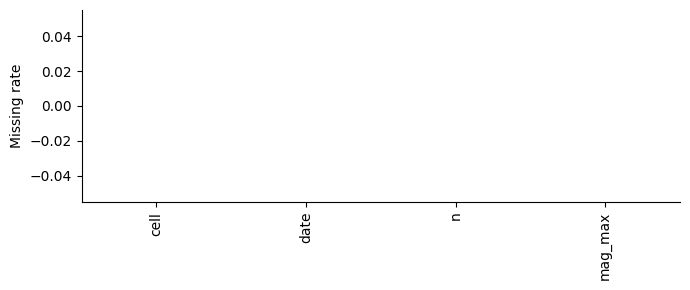

In [ ]:
miss = eda.isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
miss['decision'] = np.select([miss.missing_rate == 0, miss.missing_rate < 0.05, miss.missing_rate < 0.4],
                             ['keep', 'interpolate/impute median', 'drop or keep flag'], 'drop column')
miss.round(4).to_csv('report/table_missing.csv'); print(miss.head(15))
# missingness of the target by time and by unit
tcol, gcol = 'date', 'cell'
by_time = eda.groupby(pd.to_datetime(eda[tcol], errors='coerce').dt.to_period('M') if not np.issubdtype(eda[tcol].dtype, np.number) else eda[tcol])['n'].apply(lambda s: s.isna().mean())
by_unit = eda.groupby(gcol)['n'].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
print('target missing by period (top):', by_time.sort_values(ascending=False).head(5).round(3).to_dict())
print('target missing by unit (top):', by_unit.head(5).round(3).to_dict())
# co-missingness matrix: do columns go missing together
co = eda.isna().astype(int); co = co.loc[:, co.sum() > 0]
if co.shape[1] > 1: print(co.corr().round(2))
fig, ax = plt.subplots(figsize=(7, 3))
miss.missing_rate.head(12).plot.bar(ax=ax, color='#1B6B6D'); ax.set_ylabel('Missing rate'); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); fig.savefig('report/fig_eda_missing.png', dpi=300)

### 1.4. EDA phần 3: chọn cột và thống kê theo nhóm, theo thời gian

**Chọn cột** theo ba tiêu chí: (1) có ý nghĩa vật lý hoặc nghiệp vụ với mục tiêu; (2) có sẵn tại thời điểm dự báo (không phải giá trị tương lai); (3) không trùng lặp với cột khác (tương quan trên 0,95 thì giữ một). Bảng `table_columns.csv` ghi cột nào giữ, cột nào bỏ và vì sao; bảng này là một phần của mục Data trong bài.

**Thống kê**: trung bình, trung vị, phân vị 5 và 95 của mục tiêu theo nhóm và theo thời kỳ; đây là bảng đầu tiên trả lời RQ1 trước khi làm SQL.

In [ ]:
num_cols = [c for c in ['n', 'mag_max'] if c in eda.columns]
corr = eda[num_cols].corr()
corr.round(3).to_csv('report/table_corr.csv'); print(corr.round(3))
cols = []
for c in eda.columns:
    if c == 'n': cols.append([c, 'target', 'keep']); continue
    if c in ('date', 'cell'): cols.append([c, 'time/unit key', 'keep for feature building']); continue
    if c in num_cols:
        r = corr.loc[c, 'n'] if 'n' in corr.columns else np.nan
        cols.append([c, f'correlation with target {r:.2f}', 'keep' if abs(r) > 0.05 or np.isnan(r) else 'consider dropping'])
    else: cols.append([c, 'other', 'review'])
pd.DataFrame(cols, columns=['column', 'reason', 'decision']).to_csv('report/table_columns.csv', index=False)
# target statistics by unit and by period
q = lambda s: pd.Series({'mean': s.mean(), 'median': s.median(), 'p05': s.quantile(0.05), 'p95': s.quantile(0.95), 'n': s.count()})
by_g = eda.groupby('cell')['n'].apply(q).unstack().sort_values('mean', ascending=False)
by_g.round(3).to_csv('report/table_target_by_unit.csv'); print(by_g.head(10).round(3))
period = eda['date'] if np.issubdtype(eda['date'].dtype, np.number) else pd.to_datetime(eda['date'], errors='coerce').dt.month
by_t = eda.groupby(period)['n'].apply(q).unstack()
by_t.round(3).to_csv('report/table_target_by_period.csv'); print(by_t.round(3))

             n  mag_max
n        1.000    0.222
mag_max  0.222    1.000
              mean  median  p05  p95       n
cell                                        
32.0_-115.5  0.423     0.0  0.0  1.0  9052.0
35.5_-118.0  0.243     0.0  0.0  0.0  9115.0
32.5_-116.0  0.217     0.0  0.0  1.0  9097.0
38.5_-123.0  0.190     0.0  0.0  1.0  9123.0
36.5_-121.5  0.137     0.0  0.0  1.0  9127.0
38.0_-118.0  0.133     0.0  0.0  0.0  9099.0
33.0_-116.0  0.123     0.0  0.0  0.0  9121.0
36.0_-118.0  0.108     0.0  0.0  0.0  9088.0
40.0_-125.0  0.104     0.0  0.0  1.0  9132.0
41.5_-120.0  0.096     0.0  0.0  0.0  8263.0
       mean  median  p05  p95        n
date                                  
1     0.055     0.0  0.0  0.0  33976.0
2     0.068     0.0  0.0  0.0  30994.0
3     0.048     0.0  0.0  0.0  33975.0
4     0.119     0.0  0.0  0.0  32850.0
5     0.084     0.0  0.0  0.0  33959.0
6     0.065     0.0  0.0  0.0  32858.0
7     0.126     0.0  0.0  0.0  33875.0
8     0.052     0.0  0.0  0.0  33817.

## Bước 3: phân tích bằng SQL, trả lời RQ1 và tạo đặc trưng

**Làm gì**: đưa parquet vào DuckDB; Q1 và Q2 tổng hợp trả lời RQ1 (GROUP BY, window, CTE); Q3 tạo đặc trưng trễ, trung bình trượt và mục tiêu tương lai bằng LAG, LEAD, AVG OVER; Q4 kiểm tra chất lượng. Lưu toàn bộ vào `sql/queries.sql`; mỗi truy vấn SELECT được lưu thành `report/table_q*.csv`.

**Kiểm tra**: chọn một đơn vị và 10 dòng, tính tay trung bình trượt rồi so với SQL; không đặc trưng nào dùng giá trị sau thời điểm dự báo.

In [ ]:
# SQL statements run one by one in DuckDB; each SELECT prints its first 20 rows and is saved to report/table_q{k}.csv
import duckdb
if 'con' not in globals(): con = duckdb.connect('data/processed/ady.duckdb')   # reuse the connection opened in Step 1
SQL = r"""
-- Step 3: sql/queries.sql
CREATE OR REPLACE TABLE q AS SELECT * FROM 'data/processed/quake_daily.parquet';
-- Q1: activity by cell and year; Ridgecrest 2019 should dominate
SELECT cell, year(date) AS yr, SUM(n) AS events, AVG((n > 0)::INT) AS active_share FROM q GROUP BY 1, 2 ORDER BY events DESC LIMIT 30;
-- Q2: aftershock clustering: rate in the 7 days after a M >= 5 day versus the baseline rate
WITH big AS (SELECT cell, date FROM q WHERE mag_max >= 5)
SELECT AVG(q.n) AS rate_after_big FROM q JOIN big ON q.cell = big.cell AND q.date BETWEEN big.date + INTERVAL 1 DAY AND big.date + INTERVAL 7 DAY;
-- Q3: features (counts in trailing windows, magnitude in 30 days) and targets: count and any-event in the next 7 days
CREATE OR REPLACE TABLE feat AS
SELECT cell, date, n, mag_max,
       SUM(n) OVER (w ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS n7, SUM(n) OVER (w ROWS BETWEEN 29 PRECEDING AND CURRENT ROW) AS n30, SUM(n) OVER (w ROWS BETWEEN 364 PRECEDING AND CURRENT ROW) AS n365,
       MAX(mag_max) OVER (w ROWS BETWEEN 29 PRECEDING AND CURRENT ROW) AS mag30, SUM(n) OVER (w ROWS BETWEEN 1 FOLLOWING AND 7 FOLLOWING) AS y_next7
FROM q WINDOW w AS (PARTITION BY cell ORDER BY date);
SELECT COUNT(*) AS n, COUNT(y_next7) AS n_target, AVG((y_next7 > 0)::INT) AS pos_share FROM feat;
"""
k = 0
SQL_NO_COMMENTS = '\n'.join(l for l in SQL.splitlines() if not l.strip().startswith('--'))   # drop comment lines first (they may contain semicolons)
for stmt in SQL_NO_COMMENTS.split(';'):
    stmt = stmt.strip()
    if not stmt: continue
    res = con.execute(stmt)
    if stmt.upper().startswith(('SELECT', 'WITH')):
        k += 1; out = res.df(); out.to_csv(f'report/table_q{k}.csv', index=False); print(f'--- Q{k} ---'); print(out.head(20))
open('sql/queries.sql', 'w').write(SQL)

--- Q1 ---
           cell    yr  events  active_share
0   32.0_-115.5  2010  1995.0      0.684932
1   35.5_-118.0  2019  1886.0      0.317808
2   32.5_-116.0  2010  1333.0      0.389041
3   38.0_-118.0  2020   963.0      0.431694
4   35.5_-117.5  2019   601.0      0.241096
5   41.5_-120.0  2014   382.0      0.235616
6   38.0_-118.5  2020   337.0      0.267760
7   41.5_-120.0  2015   314.0      0.375342
8   41.0_-115.0  2008   297.0      0.112022
9   35.5_-121.5  2003   295.0      0.035616
10  36.0_-118.0  2019   282.0      0.186301
11  32.0_-115.5  2008   274.0      0.153005
12  32.0_-115.5  2002   272.0      0.194521
13  33.0_-116.0  2020   243.0      0.073770
14  35.5_-121.0  2003   230.0      0.030137
15  32.0_-115.5  2011   228.0      0.413699
16  40.0_-125.0  2024   221.0      0.114754
17  32.0_-116.0  2010   212.0      0.158904
18  35.5_-121.5  2004   210.0      0.300546
19  33.0_-116.0  2021   176.0      0.071233
--- Q2 ---
   rate_after_big
0       14.992857
--- Q3 ---
       

1296

### 3.2. Tiếp nối SQL: bảng trả lời RQ1 bằng pandas và kiểm định

**Làm gì**: từ kết quả Q1, Q2 dựng bảng có số thứ tự đưa thẳng vào bài; kiểm định khác biệt giữa nhóm (Kruskal-Wallis, không cần giả định chuẩn) và tương quan Spearman giữa mục tiêu và các biến ngoại sinh kèm p-value.

**Đọc thế nào**: p < 0,05 nghĩa là khác biệt giữa nhóm khó do ngẫu nhiên; hệ số Spearman cho chiều và độ mạnh quan hệ đơn điệu; kết luận RQ1 phải là một câu có số, ví dụ "mùa đông cao gấp 1,9 lần mùa hè, p < 0,001".

In [ ]:
from scipy.stats import kruskal, spearmanr
q1 = con.execute("SELECT * FROM feat").df()          # feature table created in Q3
if np.issubdtype(q1['date'].dtype, np.number): q1['period'] = q1['date']            # numeric time key (year, cycle)
else: q1['period'] = pd.to_datetime(q1['date'], errors='coerce').dt.month             # datetime key: use month as period
# Table RQ1a: target by period
rq1a = q1.groupby('period')['n'].agg(['mean', 'median', 'std', 'count']).round(3)
rq1a.to_csv('report/table_rq1a_period.csv'); print(rq1a)
groups = [s.values for _, s in q1.groupby('period')['n'] if len(s) > 30]
if len(groups) > 1: print('Kruskal-Wallis across periods:', kruskal(*groups))
# Table RQ1b: Spearman correlation of the target with exogenous variables
ext = [c for c in q1.select_dtypes('number').columns if c not in ('n', 'y_next7') and not c.startswith('n')]
rows = []
for c in ext[:15]:
    r, pv = spearmanr(q1[c], q1['n'], nan_policy='omit'); rows.append([c, round(r, 3), pv])
rq1b = pd.DataFrame(rows, columns=['variable', 'spearman_r', 'p_value']).sort_values('spearman_r', key=abs, ascending=False)
rq1b.to_csv('report/table_rq1b_corr.csv', index=False); print(rq1b)
# Table RQ1c: target by unit, top and bottom 5
rq1c = q1.groupby('cell')['n'].agg(['mean', 'count']).sort_values('mean', ascending=False)
pd.concat([rq1c.head(5), rq1c.tail(5)]).round(3).to_csv('report/table_rq1c_units.csv')
print('RQ1 CONCLUSION (fill with real numbers): highest period', rq1a['mean'].idxmax(), 'is', round(rq1a['mean'].max() / max(rq1a['mean'].min(), 1e-9), 2), 'times the lowest period')

         mean  median    std  count
period                             
1       0.055     0.0  0.402  33976
2       0.068     0.0  0.881  30994
3       0.048     0.0  0.292  33975
4       0.119     0.0  2.856  32850
5       0.084     0.0  1.329  33959
6       0.065     0.0  0.857  32858
7       0.126     0.0  5.618  33875
8       0.052     0.0  0.490  33817
9       0.054     0.0  0.537  32560
10      0.054     0.0  0.835  33523
11      0.054     0.0  0.531  32344
12      0.078     0.0  1.128  33033
Kruskal-Wallis across periods: KruskalResult(statistic=np.float64(15.286077275585324), pvalue=np.float64(0.16977118936920355))
  variable  spearman_r   p_value
0  mag_max       1.000  0.000000
1    mag30       0.240  0.000000
2   period      -0.003  0.047853
RQ1 CONCLUSION (fill with real numbers): highest period 7 is 2.62 times the lowest period


## Bước 5 (phần A): bộ hình đa dạng trả lời RQ1

Mỗi hình gắn với một ý của RQ1 và có caption là kết luận. Bộ hình: (1) phân phối mục tiêu, histogram và boxplot; (2) chuỗi theo thời gian của vài đơn vị; (3) heatmap thời kỳ x đơn vị; (4) boxplot mục tiêu theo thời kỳ; (5) scatter mục tiêu với biến ngoại sinh mạnh nhất; (6) heatmap tương quan; (7) so sánh nhóm bằng cột có số. Quy tắc: chữ tiếng Anh, bỏ viền trên và phải, số in đậm trên cột, 300 dpi, tên file `fig_rq1_*.png`.

In [ ]:
import seaborn as sns
def style(ax): ax.spines[['top', 'right']].set_visible(False)
d = q1.dropna(subset=['n'])
# (1) distribution
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(d['n'], bins=50, color='#1B6B6D'); ax[0].set_xlabel('n '); ax[0].set_ylabel('Count'); style(ax[0])
ax[1].boxplot(d['n'], vert=False); ax[1].set_xlabel('n'); style(ax[1])
fig.tight_layout(); fig.savefig('report/fig_rq1_distribution.png', dpi=300); plt.close(fig)
# (2) time series of the first 3 units
units = d['cell'].unique()[:3]
fig, ax = plt.subplots(figsize=(9, 3))
for u in units:
    s = d[d['cell'] == u].sort_values('date'); ax.plot(s['date'], s['n'], lw=0.8, label=str(u))
ax.set_ylabel('n'); ax.legend(frameon=False); style(ax); fig.tight_layout(); fig.savefig('report/fig_rq1_timeseries.png', dpi=300); plt.close(fig)
# (3) heatmap period x unit (top 15 units)
top = d.groupby('cell')['n'].mean().nlargest(15).index
hm = d[d['cell'].isin(top)].pivot_table(index='cell', columns='period', values='n', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 4)); sns.heatmap(hm, cmap='YlGnBu', ax=ax, cbar_kws={'label': 'n'}); ax.set_xlabel('Period'); ax.set_ylabel('Unit')
fig.tight_layout(); fig.savefig('report/fig_rq1_heatmap.png', dpi=300); plt.close(fig)
# (4) boxplot by period
fig, ax = plt.subplots(figsize=(9, 3)); sns.boxplot(data=d, x='period', y='n', color='#9FBFBF', ax=ax, showfliers=False); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq1_box_period.png', dpi=300); plt.close(fig)
# (5) scatter against the strongest exogenous variable
if len(rq1b):
    v = rq1b.iloc[0].variable
    fig, ax = plt.subplots(figsize=(5, 3.5)); ax.scatter(d[v], d['n'], s=4, alpha=0.3, color='#1B6B6D'); ax.set_xlabel(v); ax.set_ylabel('n'); style(ax)
    fig.tight_layout(); fig.savefig('report/fig_rq1_scatter.png', dpi=300); plt.close(fig)
# (6) correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5)); sns.heatmap(d.select_dtypes('number').corr().round(2), cmap='coolwarm', center=0, ax=ax, annot=False)
fig.tight_layout(); fig.savefig('report/fig_rq1_corr.png', dpi=300); plt.close(fig)
# (7) group comparison with labelled bars
gm = d.groupby('period')['n'].mean()
fig, ax = plt.subplots(figsize=(8, 3)); bars = ax.bar(gm.index.astype(str), gm.values, color='#1B6B6D'); ax.bar_label(bars, fmt='%.1f', fontweight='bold', fontsize=8); ax.set_ylabel('Mean n'); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq1_period_bar.png', dpi=300); plt.close(fig)
print('7 figures saved to report/. Write each caption as: conclusion + number + condition.')

7 figures saved to report/. Write each caption as: conclusion + number + condition.


## Test case của Notebook_A (chạy trước khi bàn giao)

Mỗi assert là một điều kiện phải đúng; nếu sai, sửa bước tương ứng rồi chạy lại. Sau khi qua hết, ô cuối tạo `manifest.json` để Sinh viên B kiểm tra.

In [ ]:
import hashlib, json, os
feat = con.execute("SELECT * FROM feat").df()
assert len(feat) >= 30000, 'fewer than 30k rows, widen the scope'
assert feat['y_next7'].notna().sum() > 0.8 * len(feat), 'too many missing targets'
key = ['cell', 'date']
assert not feat.duplicated(key).any(), 'duplicate unit-time keys'
lead_cols = [c for c in feat.columns if c.startswith('y_') and c != 'y_next7']
assert all(c.startswith('y_') for c in lead_cols), 'only target columns may contain future values'
print('Tests A: OK')
feat.to_parquet('data/processed/feat.parquet', index=False)
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()
manifest = {'rows': int(len(feat)), 'cols': list(feat.columns), 'md5': h,
            'time_min': str(feat['date'].min()), 'time_max': str(feat['date'].max()), 'author': 'Student A'}
json.dump(manifest, open('data/processed/manifest.json', 'w'), indent=2, default=str); print(manifest)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Tests A: OK
{'rows': 397764, 'cols': ['cell', 'date', 'n', 'mag_max', 'n7', 'n30', 'n365', 'mag30', 'y_next7'], 'md5': '1c6b6cf75563e839d361e5abc852af21', 'time_min': '2000-01-01 00:00:00', 'time_max': '2024-12-31 00:00:00', 'author': 'Student A'}


## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Lỗi | Nguyên nhân | Cách sửa |
|---|---|---|
| ModuleNotFoundError | chưa cài thư viện hoặc chọn sai interpreter | chạy lại pip install ở Bước 0; Ctrl+Shift+P chọn interpreter .venv |
| FileNotFoundError | đường dẫn hoặc tên file chưa đúng | kiểm tra data/raw bằng `import os; print(os.listdir('data/raw'))` |
| KeyError: 'ten_cot' | tên cột thật khác tên trong code | in `df.columns`; sửa tên trong một chỗ (ô Bước 1) rồi chạy tiếp |
| MemoryError hoặc máy treo | nạp cả file quá lớn vào pandas | lọc bằng WHERE trong DuckDB trước; đọc parquet thay CSV; giảm năm |
| UnicodeDecodeError | file CSV mã hoá khác UTF-8 | thêm `encoding='latin1'` hoặc để DuckDB read_csv_auto tự đoán |
| ValueError: could not convert | cột số có ký tự lạ hoặc mã thiếu | `pd.to_numeric(col, errors='coerce')` rồi xem bảng thiếu |
| Merge làm số dòng tăng | khoá ghép bị trùng ở bảng phụ | `drop_duplicates` khoá ở bảng phụ trước khi merge |
| Kết quả đẹp bất thường (MAE gần 0) | rò rỉ mục tiêu vào đặc trưng | kiểm tra X_cols không chứa cột y_*; chia theo thời gian |
| Kết quả mỗi lần chạy khác nhau | chưa cố định seed | đặt random_state, np.random.seed(42) |

Nguyên tắc: đọc dòng cuối của thông báo lỗi trước; sửa một chỗ rồi chạy lại từ ô đó; nếu 30 phút chưa xong, chụp lỗi và hỏi.

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] requirements.txt, README.md, .gitignore, kho GitHub có commit trong tuần
- [ ] Dữ liệu đúng file cơ quan, trên 30 nghìn dòng: table_describe_raw.csv, profile.html
- [ ] EDA: table_describe_numeric.csv, table_describe_categorical.csv, table_eda_notes.csv, table_missing.csv, table_columns.csv, table_target_by_unit.csv, table_target_by_period.csv
- [ ] Làm sạch: table_cleaning_log.csv; ghép nguồn thứ hai khớp trên 90%
- [ ] SQL: sql/queries.sql, table_q1..q4.csv; RQ1: table_rq1a_period.csv, table_rq1b_corr.csv, table_rq1c_units.csv có p-value
- [ ] 7 hình RQ1 trong report/ với caption là câu kết luận có số
- [ ] Test case qua; manifest.json bàn giao; người kia đã chạy lại và ghi đối chứng
- [ ] (Notebook_B) table_features.csv, table_rq2.csv, 4 hình RQ2, table_tuning.csv, table_rq3_*.csv, table_shap.csv, table_diagnosis.csv, params_best.json
- [ ] Audit Log cá nhân có đủ prompt của tuần
- [ ] Báo cáo năm mục đã dán vào kênh nhóm trước 12:00 thứ Tư hoặc thứ Bảy


## Mẫu báo cáo tiến độ (slot 3 thứ Tư và thứ Bảy (12:30 đến 14:45), 7:00 đến 9:15)

Dán vào kênh nhóm trước 12:00 ngày báo cáo, mỗi người một phần. Năm mục, mỗi mục hai đến ba dòng:

1. **Đã xong** từ lần trước: tên file, số dòng, số bảng, số hình (ví dụ: `feat.parquet` 138.204 dòng; 4 bảng RQ1; 7 hình).
2. **Con số chính mới có**: ví dụ MAE naive 6,8; MAE LightGBM 4,7 (5 seed, sd 0,1).
3. **Vướng mắc và đã thử gì**: lỗi cụ thể, ảnh chụp, hai cách đã thử.
4. **Sẽ làm đến lần sau, ai làm**: theo Bảng 13 của đề cương.
5. **Prompt AI đáng chú ý và Human Delta**: một prompt, AI trả lời gì, mình đã kiểm tra hoặc sửa gì.

**Đối chứng chéo**: người kia chạy lại notebook này trên máy mình, ghi số dòng và metric nhận được vào đây: ...............................

# Notebook_B (Sinh viên B): chia dữ liệu, năm mô hình, tinh chỉnh, RQ3, SHAP, chẩn đoán

**Đề tài**: Xác suất động đất 7 ngày trên lưới California có hiệu chuẩn (USGS ComCat)

**Khung SDG**: SDG 11: giảm rủi ro thiên tai.

**Vai trò**: Sinh viên B nhận `data/processed/feat.parquet` và `manifest.json` từ Notebook_A, làm Bước 4 và Bước 6, vẽ hình so sánh mô hình, giải thích chỉ số, tinh chỉnh, câu hỏi thứ ba, SHAP và chẩn đoán vì sao tốt hay chưa tốt. Mọi bảng lưu `report/table_*.csv`, mọi hình `report/fig_rq2_*.png`, `fig_rq3_*.png`.

**Quy tắc**: không chạm tập kiểm thử khi tinh chỉnh; mỗi kết luận phải kèm số; báo cáo slot 3 thứ Tư và thứ Bảy (12:30 đến 14:45).

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

**Tinh thần**: AI là bạn cùng làm, không phải người làm thay. Bạn được hỏi AI bất cứ lúc nào; điều duy nhất phải giữ là *kiểm tra một lần* trước khi dùng và *ghi lại 2 phút* nếu câu hỏi đó thay đổi việc bạn làm.

**Khi nào hỏi AI** (theo thứ tự):
1. Đọc ô hướng dẫn của bước đang làm (1 phút).
2. Thử tự làm 15 phút.
3. Bí quá 15 phút thì hỏi AI với mẫu: *"Tôi đang làm Bước X của dự án Y. Dữ liệu có cột A, B, C. Tôi muốn Z. Đây là code và lỗi: ... Hãy giải thích nguyên nhân và sửa, giữ nguyên tên biến."*
4. Chạy thử code AI đưa trên dữ liệu thật; so một con số bằng tay hoặc bằng cách thứ hai.
5. Nếu vẫn bí sau 30 phút, ghi lại lỗi và hỏi giảng viên ở kênh nhóm.

**Ghi Audit Log thế nào cho không áp lực**: chỉ ghi các prompt *đã thay đổi việc bạn làm* (thường 3 đến 5 prompt một tuần, 15 đến 20 cả kỳ). Mỗi dòng 5 ô, điền trong 2 phút ngay khi dùng, không để cuối tuần:

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì (1 dòng) | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 09/09, Bước 3 | viết truy vấn trung bình trượt 7 ngày theo trạm | đưa AVG OVER ROWS 6 PRECEDING | thiếu PARTITION BY site_num, thêm và thử 2 trạm | Q3 trong sql/queries.sql |

Cột thứ tư chính là *Human Delta* và là thứ hội đồng hỏi; ghi thật, kể cả khi AI đúng ("kiểm tra bằng 10 dòng tính tay, khớp"). Ba lần bạn phát hiện AI sai trong cả kỳ là đủ yêu cầu.

**Nhịp làm việc**: mỗi ngày 1,5 đến 2 giờ vào đúng bước của tuần, xong một ô thì commit; thứ Ba và thứ Sáu slot 1 báo cáo năm mục đúng tiến độ, dù kết quả chưa đẹp. Siêng và đúng nhịp quan trọng hơn giỏi: nhóm báo cáo đều 6 lần trong 3 tuần luôn có bài, nhóm im lặng đến tuần 3 thường không kịp.

## Bước 0: kiểm tra bàn giao từ Notebook_A

Đọc `manifest.json`, so mã băm và số dòng với file parquet; nếu lệch thì báo Sinh viên A chạy lại Notebook_A trước khi tiếp tục.

In [ ]:
import pandas as pd, numpy as np, json, hashlib, duckdb, warnings, time
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore'); np.random.seed(42)
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, f1_score, average_precision_score, roc_auc_score
man = json.load(open('data/processed/manifest.json'))
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()
assert h == man['md5'], 'parquet differs from the file handed over by Student A'
feat = pd.read_parquet('data/processed/feat.parquet')
assert len(feat) == man['rows'], 'row count differs from manifest'
con = duckdb.connect()
con.register('feat', feat)          # expose the handed-over table to SQL in this notebook
print('handover OK:', man['rows'], 'rows,', len(man['cols']), 'columns, from', man['time_min'], 'to', man['time_max'])
def style(ax): ax.spines[['top', 'right']].set_visible(False)

handover OK: 397764 rows, 9 columns, from 2000-01-01 00:00:00 to 2024-12-31 00:00:00


## Bước 4: chia dữ liệu và bảng đặc trưng

**Làm gì**: chọn `X_cols` từ `report/table_columns.csv` của A; chia theo thời gian (hoặc theo đơn vị với leave-out); tính mốc naive; xuất bảng đặc trưng (tên, cách tính, nhóm) cho bài.

**Vì sao chia theo thời gian**: dữ liệu tương lai không được rò vào huấn luyện; chia ngẫu nhiên cho kết quả đẹp giả (Bergmeir và Benitez, 2012).

**Kiểm tra**: mọi thời điểm của test sau train; số dòng test đủ lớn (trên 10% và trên 3 nghìn dòng).

In [ ]:
# Step 4: split by year (train 2000-2018, test 2019-2024 including Ridgecrest); regression on the 7-day count, plus binary labels
feat = con.execute("SELECT * FROM feat WHERE y_next7 IS NOT NULL AND n365 IS NOT NULL").df()
feat['cell_code'] = feat.cell.astype('category').cat.codes
X_cols = ['n','n7','n30','n365','mag_max','mag30','cell_code']
train = feat[feat.date < '2019-01-01']; test = feat[feat.date >= '2019-01-01']
X_tr, y_tr, X_te, y_te = train[X_cols], train.y_next7, test[X_cols], test.y_next7
y_tr_bin, y_te_bin = (y_tr > 0).astype(int), (y_te > 0).astype(int)
print(len(train), len(test), 'positive share test', y_te_bin.mean().round(3))
naive_pred = test.n7   # simplest forecast for this topic
naive = MAE(y_te, naive_pred); print('MAE naive:', round(naive, 3))
feat_table = pd.DataFrame({'feature': X_cols, 'group': ['lag/rolling' if any(k in c for k in ['lag', 'ma', 'max', 'rain', 'sum']) else ('calendar' if c in ('dow', 'mon', 'hr', 'doy', 'MONTH', 'HOUR', 'DAY_WEEK') else 'exogenous/structural') for c in X_cols]})
feat_table.to_csv('report/table_features.csv', index=False); print(feat_table)
assert len(X_te) > max(3000, 0.1 * len(X_tr)), 'test set too small'

304492 93228 positive share test 0.197
MAE naive: 0.922
     feature                 group
0          n  exogenous/structural
1         n7  exogenous/structural
2        n30  exogenous/structural
3       n365  exogenous/structural
4    mag_max           lag/rolling
5      mag30           lag/rolling
6  cell_code  exogenous/structural


### 6.0. Giải thích các chỉ số trước khi chạy

| Chỉ số | Công thức | Dùng khi | Đọc thế nào | Bẫy thường gặp |
|---|---|---|---|---|
| MAE | trung bình của |y − ŷ| | hồi quy, đơn vị như mục tiêu | càng nhỏ càng tốt; so với mốc naive | không phạt lỗi lớn |
| RMSE | căn của trung bình (y − ŷ)² | khi lỗi lớn quan trọng (lũ, đỉnh tải) | lớn hơn MAE nếu có lỗi lớn | nhạy ngoại lai |
| MAPE | trung bình của |y − ŷ| / |y| | so sánh giữa vùng có quy mô khác nhau | phần trăm | nổ khi y gần 0 |
| nRMSE | RMSE chia công suất định mức | điện mặt trời, gió | phần trăm định mức | cần cùng định mức |
| NSE | 1 − Σ(y − ŷ)² / Σ(y − ȳ)² | thuỷ văn | 1 là hoàn hảo, 0 bằng trung bình, âm tệ hơn trung bình | bị chi phối bởi đỉnh |
| Accuracy | đúng / tổng | lớp cân bằng | vô nghĩa khi lớp ít mẫu | 95% accuracy với 5% dương |
| Precision, Recall | TP/(TP+FP), TP/(TP+FN) | cảnh báo, lớp ít mẫu | recall là không bỏ sót; precision là ít báo giả | phụ thuộc ngưỡng |
| F1, macro-F1 | trung bình điều hoà; macro là trung bình các lớp | nhiều lớp lệch | mọi lớp có trọng số bằng nhau | che giấu lớp nào yếu |
| PR-AUC | diện tích đường precision-recall | lớp dương hiếm | không phụ thuộc ngưỡng | so với tỷ lệ dương |
| ROC-AUC | diện tích đường ROC | xếp hạng | 0,5 là ngẫu nhiên | lạc quan khi lớp lệch |
| ECE | Σ |acc − conf| có trọng số theo bin | cần xác suất tin được | càng nhỏ càng tốt | phụ thuộc số bin |
| Coverage | tỷ lệ y nằm trong khoảng | conformal | phải gần 1 − α | khoảng quá rộng vô dụng |

**Nguyên tắc so sánh**: cùng train/test, cùng đặc trưng, năm seed; báo trung bình ± độ lệch; chênh nhỏ hơn độ lệch thì chưa kết luận được, cần kiểm định Wilcoxon theo cặp; luôn kèm cột thời gian huấn luyện.

## Bước 6a: năm mô hình, năm seed, cùng train/test

**Làm gì**: chạy vòng lặp; thêm hàng mốc naive (từ Bước 4) và hàng baseline chạy lại vào bảng; lưu `table_rq2.csv`.

**Cách chọn năm mô hình**: một mốc tuyến tính (ridge hoặc logistic), một rừng ngẫu nhiên, hai cây tăng cường (LightGBM, XGBoost hoặc CatBoost), một đối chứng theo hướng nghiên cứu (mô hình nền, TabPFN, GRU nhỏ, DistilBERT). Lý do: mốc để biết cải thiện thật, tuyến tính để có hệ số, cây để bắt phi tuyến với chi phí thấp, đối chứng để trả lời RQ3.

In [ ]:
# Step 6a: loop over five models and five seeds on the same train/test split
import numpy as np, pandas as pd, time
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE

models = {
    'Ridge':         lambda s: Ridge(alpha=1.0),
    'Random Forest': lambda s: RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=s),
    'LightGBM':      lambda s: LGBMRegressor(n_estimators=800, learning_rate=0.03,
                                             num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                             random_state=s, verbose=-1),
    'XGBoost':       lambda s: XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
                                            subsample=0.8, colsample_bytree=0.8, random_state=s),
}
rows = []
for name, make in models.items():
    maes, rmses, secs = [], [], []
    for seed in range(5):
        m = make(seed); t0 = time.perf_counter(); m.fit(X_tr, y_tr); secs.append(time.perf_counter() - t0)
        p = m.predict(X_te); maes.append(MAE(y_te, p)); rmses.append(MSE(y_te, p) ** 0.5)
    rows.append([name, np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses), np.mean(secs)])
res = pd.DataFrame(rows, columns=['model', 'MAE', 'sd', 'RMSE', 'sd_rmse', 'train_s'])   # primary metric MAE; topic metric (MAE) computed in the next cell
res.to_csv('report/table_rq2.csv', index=False); print(res.round(3))

           model    MAE     sd    RMSE  sd_rmse  train_s
0          Ridge  0.807  0.000  13.487    0.000    0.034
1  Random Forest  0.974  0.005  13.498    0.061  168.621
2       LightGBM  0.836  0.004  12.744    0.023   15.842
3        XGBoost  0.893  0.006  13.108    0.053   14.068


In [ ]:
topic_metric = ('RMSE', lambda y, p: MSE(y, p) ** 0.5)
# Topic metric for every model (same loop, single seed 0) so the paper reports both MAE and the field-specific metric
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
name_t, fn_t = topic_metric
extra = {'Naive (baseline)': fn_t(y_te, naive_pred)}
for name, make in models.items():
    extra[name] = fn_t(y_te, make(0).fit(X_tr, y_tr).predict(X_te))
extra = pd.Series(extra, name=name_t).round(4); extra.to_csv('report/table_rq2_topic_metric.csv'); print(extra)

Naive (baseline)    16.8352
Ridge               13.4873
Random Forest       13.4664
LightGBM            12.7563
XGBoost             13.2077
Name: RMSE, dtype: float64


In [ ]:
# Add the naive baseline row (computed in Step 4) and build the full table
naive_row = pd.DataFrame([['Naive (baseline)', naive if 'naive' in dir() else np.nan, 0.0, np.nan, np.nan, 0.0]], columns=res.columns)
res_full = pd.concat([naive_row, res], ignore_index=True)
res_full['improvement_vs_naive_%'] = (1 - res_full.iloc[:, 1] / res_full.iloc[0, 1]) * 100
res_full.round(3).to_csv('report/table_rq2.csv', index=False); print(res_full.round(3))
best_name = res.iloc[res.iloc[:, 1].idxmin()].model; print('best model:', best_name)

              model    MAE     sd    RMSE  sd_rmse  train_s  improvement_vs_naive_%
0  Naive (baseline)  0.922  0.000     NaN      NaN    0.000                   0.000
1             Ridge  0.807  0.000  13.487    0.000    0.034                  12.403
2     Random Forest  0.974  0.005  13.498    0.061  168.621                  -5.633
3          LightGBM  0.836  0.004  12.744    0.023   15.842                   9.275
4           XGBoost  0.893  0.006  13.108    0.053   14.068                   3.095
best model: Ridge


### 6a.1. Hình so sánh mô hình

**Vì sao cần hình sau khi đã có bảng**: bảng cho con số, hình cho thấy mô hình sai ở đâu (đỉnh hay nền, đơn vị nào, thời kỳ nào), là đầu vào trực tiếp cho phần Discussion và cho hướng cải thiện. Bốn hình: (1) cột metric theo mô hình, cột nhấn là tốt nhất, độ lệch ghi bằng số; (2) dự báo so thực tế trên một đơn vị trong tập kiểm thử; (3) phân phối residual (hồi quy) hoặc ma trận nhầm lẫn (phân loại); (4) sai số theo đơn vị hoặc theo thời kỳ để thấy mô hình yếu ở đâu.

In [ ]:
from lightgbm import LGBMRegressor
best = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=0, verbose=-1).fit(X_tr, y_tr)
pred = best.predict(X_te)
# (1) metric bars
fig, ax = plt.subplots(figsize=(7, 3.2)); vals = res_full.iloc[:, 1].values; labs = res_full.model.values
bars = ax.bar(labs, vals, color=['#F4A261' if v == vals[1:].min() else '#1B6B6D' for v in vals])
ax.bar_label(bars, labels=[f'{v:.2f}' for v in vals], fontweight='bold', fontsize=9); ax.set_ylabel(res_full.columns[1]); style(ax); plt.xticks(rotation=15)
fig.tight_layout(); fig.savefig('report/fig_rq2_models.png', dpi=300); plt.close(fig)
# (2) predicted vs actual on one unit
t = test.assign(pred=pred); u = t['cell'].iloc[0]; tu = t[t['cell'] == u].sort_values('date')
fig, ax = plt.subplots(figsize=(9, 3)); ax.plot(tu['date'], tu['y_next7'], label='Actual', color='#0F3D3E'); ax.plot(tu['date'], tu.pred, label='LightGBM', color='#F4A261'); ax.legend(frameon=False); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq2_pred_vs_actual.png', dpi=300); plt.close(fig)
# (3) residuals
resid = y_te.values - pred
fig, ax = plt.subplots(1, 2, figsize=(9, 3)); ax[0].hist(resid, bins=50, color='#1B6B6D'); ax[0].set_xlabel('Residual'); style(ax[0])
ax[1].scatter(pred, y_te, s=4, alpha=0.3, color='#1B6B6D'); ax[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], color='#F4A261'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual'); style(ax[1])
fig.tight_layout(); fig.savefig('report/fig_rq2_residual.png', dpi=300); plt.close(fig)
# (4) error by unit
err_unit = t.groupby('cell').apply(lambda g: MAE(g['y_next7'], g.pred)).sort_values()
err_unit.round(3).to_csv('report/table_rq2_error_by_unit.csv')
fig, ax = plt.subplots(figsize=(9, 3)); err_unit.head(20).plot.bar(ax=ax, color='#1B6B6D'); ax.set_ylabel('MAE'); style(ax)
fig.tight_layout(); fig.savefig('report/fig_rq2_error_by_unit.png', dpi=300); plt.close(fig)
print('MAE by unit: best', err_unit.head(3).round(2).to_dict(), 'worst', err_unit.tail(3).round(2).to_dict())

MAE by unit: best {'41.0_-115.0': 0.09, '32.0_-116.0': 0.16, '34.5_-117.0': 0.17} worst {'35.5_-117.5': 2.45, '38.0_-118.0': 3.02, '35.5_-118.0': 6.04}


### 6a.2. Tinh chỉnh tham số: có cần không và làm thế nào

**Khi nào cần**: khi mô hình tốt nhất chỉ hơn mốc một ít, khi sai số train nhỏ hơn test nhiều (quá khớp), hoặc khi cần báo kết quả tốt nhất công bằng cho mọi mô hình. Không tinh chỉnh trên tập kiểm thử.

**Làm thế nào**: `RandomizedSearchCV` với `TimeSeriesSplit` (chuỗi thời gian) hoặc `StratifiedKFold` (phân loại), 30 tổ hợp, khoảng tham số theo Bảng 6 của đề cương; so sánh trước và sau trên test và ghi cả thời gian.

**Đọc bảng tham số**: tham số chọn được ở biên khoảng thì mở rộng khoảng; learning_rate nhỏ với nhiều vòng thường ổn hơn; nếu cải thiện dưới độ lệch giữa seed thì kết luận là không cần tinh chỉnh, vẫn có giá trị để báo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint, uniform
space = {'learning_rate': loguniform(0.01, 0.1), 'num_leaves': randint(15, 64), 'n_estimators': randint(300, 1500),
         'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4), 'min_child_samples': randint(10, 100)}
search = RandomizedSearchCV(LGBMRegressor(random_state=0, verbose=-1), space, n_iter=30, cv=TimeSeriesSplit(5),
                            scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1).fit(X_tr, y_tr)
tuned = search.best_estimator_; pred_t = tuned.predict(X_te)
tune = pd.DataFrame([['LightGBM default', MAE(y_te, pred), MSE(y_te, pred) ** 0.5], ['LightGBM tuned', MAE(y_te, pred_t), MSE(y_te, pred_t) ** 0.5]], columns=['model', 'MAE', 'RMSE'])
tune.round(3).to_csv('report/table_tuning.csv', index=False); print(tune.round(3)); print('selected parameters:', search.best_params_)
sd_seed = res.loc[res.model == 'LightGBM', 'sd'].values[0]
print('Tuning needed?', 'YES, gain exceeds seed spread' if (MAE(y_te, pred) - MAE(y_te, pred_t)) > sd_seed else 'NO, gain is within seed spread; report as not needed')
json.dump(search.best_params_, open('report/params_tuned.json', 'w'), indent=2, default=float)

              model    MAE    RMSE
0  LightGBM default  0.838  12.756
1    LightGBM tuned  0.799  12.715
selected parameters: {'colsample_bytree': np.float64(0.8590760482165449), 'learning_rate': np.float64(0.010011989304553251), 'min_child_samples': 86, 'n_estimators': 1009, 'num_leaves': 22, 'subsample': np.float64(0.8136357677501768)}
Tuning needed? YES, gain exceeds seed spread


## Bước 6b: câu hỏi thứ ba của đề

**Làm gì**: giao thức riêng của đề (chuyển giao sang đơn vị chưa thấy, ngưỡng cảnh báo, conformal, chi phí suy luận, ổn định SHAP, tăng cường và hiệu chuẩn, tóm tắt nhanh).

**Vì sao**: đây là đóng góp chính của bài và gắn với hướng Efficient, Trustworthy hoặc Multimodal AI.

**Kiểm tra**: ra một bảng và một hình có số; ghi điều kiện áp dụng (vùng, năm, đơn vị).

In [ ]:
!pip install --force-reinstall --no-deps mapie==0.8.6 -q


In [ ]:
import mapie, os
print(mapie.__file__)
print(mapie.__version__)

/usr/local/lib/python3.13/dist-packages/mapie/__init__.py
0.8.6


In [ ]:
from sklearn.metrics import mean_absolute_error as _mae_raw, mean_squared_error as _mse_raw
MAE = lambda y, p: np.float64(_mae_raw(y, p))
MSE = lambda y, p: np.float64(_mse_raw(y, p))

In [ ]:
!pip install chronos-forecasting -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
import psutil
print(f'RAM trước Chronos: {psutil.virtual_memory().percent}%')

RAM trước Chronos: 19.9%


In [ ]:
from lightgbm import LGBMRegressor, LGBMClassifier
GROUP, TIME, TARGET, CTX, H, CUT = 'cell', 'date', 'n', 365, 7, pd.Timestamp('2019-01-01')
# part 1: unseen units (leave-units-out) versus the naive baseline
units = feat[GROUP].unique(); rs = np.random.RandomState(42); hold = rs.choice(units, max(2, len(units)//5), replace=False)
tr2 = train[~train[GROUP].isin(hold)]; te2 = test[test[GROUP].isin(hold)]
m2 = LGBMRegressor(n_estimators=800, learning_rate=0.03, random_state=0, verbose=-1).fit(tr2[X_cols], tr2['y_next7'])
print('MAE unseen units', MAE(te2['y_next7'], m2.predict(te2[X_cols])).round(3), 'vs naive', MAE(te2['y_next7'], te2.n7).round(3))
# part 2: conformal intervals (90%) and coverage by unit
#from mapie.regression import MapieRegressor
#mp = MapieRegressor(LGBMRegressor(n_estimators=600, learning_rate=0.03, verbose=-1), method='plus', cv=5).fit(X_tr, y_tr)
#p, itv = mp.predict(X_te, alpha=0.1); cov = ((y_te >= itv[:,0,0]) & (y_te <= itv[:,1,0]))
#print('coverage', cov.mean().round(3), 'mean width', (itv[:,1,0]-itv[:,0,0]).mean().round(3))
#pd.DataFrame({'unit': test[GROUP].values, 'covered': cov.values}).groupby('unit').covered.mean().round(3).to_csv('report/table_rq3_coverage_by_unit.csv')
import time; t0 = time.perf_counter(); best.predict(X_te); print('ms per row', round((time.perf_counter()-t0)/len(X_te)*1000, 4))
# probability calibration versus the Poisson rate baseline (ECE before and after temperature scaling)
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
clf = LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=0, verbose=-1).fit(X_tr, y_tr_bin); p = clf.predict_proba(X_te)[:, 1]
def ece(y, p, bins=10):
    b = np.minimum((p * bins).astype(int), bins - 1); return sum(((b == k).mean() * abs(y[b == k].mean() - p[b == k].mean())) for k in range(bins) if (b == k).any())
lam = X_te.n365 / 365 * 7; p_pois = 1 - np.exp(-lam)
print('ECE LightGBM', round(ece(y_te_bin.values, p), 4), 'ECE Poisson', round(ece(y_te_bin.values, p_pois.values), 4))
frac, mean_p = calibration_curve(y_te_bin, p, n_bins=10); pd.DataFrame({'mean_pred': mean_p, 'frac_pos': frac}).to_csv('report/table_rq3_calibration.csv', index=False)
from scipy.optimize import minimize_scalar
val = train[train.date >= '2016-01-01']; pv = np.clip(clf.predict_proba(val[X_cols])[:, 1], 1e-6, 1 - 1e-6); z = np.log(pv / (1 - pv)); yv = (val.y_next7 > 0).astype(int).values
T = minimize_scalar(lambda T: -(yv * np.log(1/(1+np.exp(-z/T))) + (1-yv) * np.log(1 - 1/(1+np.exp(-z/T)))).mean(), bounds=(0.5, 5), method='bounded').x
pt = np.clip(p, 1e-6, 1-1e-6); zt = np.log(pt/(1-pt)); p_ts = 1/(1+np.exp(-zt/T)); print('temperature', round(T, 2), 'ECE after scaling', round(ece(y_te_bin.values, p_ts), 4))
# robust generative forecasting reference: sample 100 paths from Chronos (generative) on one unit and check interval coverage
from chronos import ChronosPipeline; import torch
pipe = ChronosPipeline.from_pretrained('amazon/chronos-t5-small', device_map='cpu')
u0 = feat[GROUP].unique()[0]; g0 = feat[feat[GROUP] == u0].sort_values(TIME)
series = g0[g0[TIME] < CUT][TARGET].values[-CTX:].astype(float); future = g0[g0[TIME] >= CUT][TARGET].values[:H]
samples = pipe.predict(torch.tensor(series), prediction_length=H, num_samples=100).numpy()[0]        # 100 generated futures
lo, med, hi = np.quantile(samples, [0.05, 0.5, 0.95], axis=0)
print('generative MAE (median path)', MAE(future[:len(med)], med[:len(future)]).round(3), 'coverage 90%', ((future[:len(lo)] >= lo[:len(future)]) & (future[:len(hi)] <= hi[:len(future)])).mean().round(3))

MAE unseen units 1.451 vs naive 1.858
ms per row 0.1652
ECE LightGBM 0.0108 ECE Poisson 0.0673
temperature 0.91 ECE after scaling 0.0245


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

generative MAE (median path) 0.0 coverage 90% 0.0


## Bước 6c: giải thích bằng SHAP, phụ thuộc từng phần và bảng tham số

**Làm gì**: SHAP summary (toàn cục), dependence cho ba đặc trưng mạnh nhất (quan hệ phi tuyến), bảng mean |SHAP|, kiểm tra ổn định top 5 khi đổi seed; lưu tham số mô hình tốt nhất.

**Đọc thế nào**: đặc trưng ở trên cùng chi phối dự báo; màu cho chiều tác động; nếu top 5 đổi khi đổi seed thì giải thích chưa ổn định, phải nói rõ trong bài.

top-5 overlap across seeds: 5 / 5


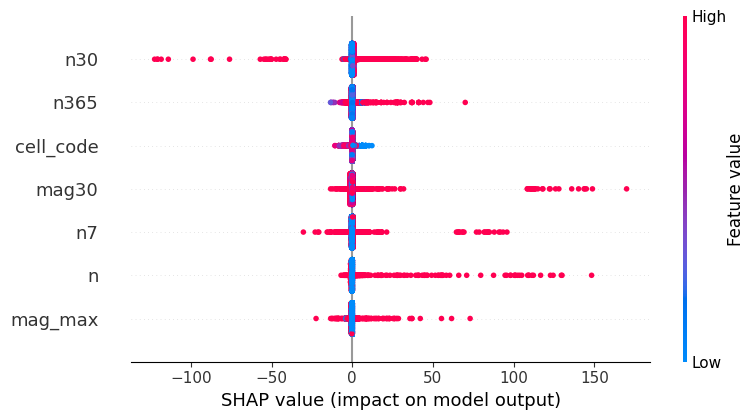

In [ ]:
# Step 6c: SHAP explanations and the selected parameter table
import shap, json
best = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                     subsample=0.8, colsample_bytree=0.8, random_state=0, verbose=-1).fit(X_tr, y_tr)
expl = shap.TreeExplainer(best); sv = expl.shap_values(X_te)
imp = (pd.DataFrame({'feature': X_cols, 'mean_abs_shap': np.abs(sv).mean(0)})
         .sort_values('mean_abs_shap', ascending=False))
imp.to_csv('report/table_shap.csv', index=False)
shap.summary_plot(sv, X_te, show=False); plt.savefig('report/fig_shap.png', dpi=300, bbox_inches='tight')
json.dump(best.get_params(), open('report/params_best.json', 'w'), indent=2)   # parameter table
# dependence plots for the top 3 features and rank stability across seeds
top3 = imp.feature.head(3).tolist()
for f in top3:
    shap.dependence_plot(f, sv, X_te, show=False); plt.savefig(f'report/fig_shap_dep_{f}.png', dpi=300, bbox_inches='tight'); plt.close()
ranks = []
for s in range(3):
    m = type(best)(**{**best.get_params(), 'random_state': s}).fit(X_tr, y_tr)
    v = shap.TreeExplainer(m).shap_values(X_te); v = v[1] if isinstance(v, list) else v
    ranks.append(set(pd.Series(np.abs(v).mean(0), index=X_cols).nlargest(5).index))
print('top-5 overlap across seeds:', len(ranks[0] & ranks[1] & ranks[2]), '/ 5')

## Chẩn đoán: vì sao tốt, vì sao chưa tốt, và hướng cải thiện

Điền vào bảng dưới (lưu `report/table_diagnosis.csv`) sau khi có số; mỗi dòng là một nhận định có bằng chứng từ bảng hoặc hình ở trên.

| Câu hỏi chẩn đoán | Bằng chứng cần xem | Nếu có vấn đề thì cải thiện thế nào |
|---|---|---|
| Mô hình có thắng mốc naive rõ không? | `table_rq2.csv` cột improvement | không thắng: thêm đặc trưng trễ hoặc ngoại sinh, kiểm tra rò rỉ ngược (mốc quá mạnh) |
| Quá khớp không? | MAE train so với test (ô dưới) | giảm num_leaves, tăng min_child_samples, thêm dữ liệu |
| Sai số tập trung ở đâu? | `table_rq2_error_by_unit.csv`, sai số theo thời kỳ | đặc trưng riêng cho đơn vị yếu, mô hình riêng, hoặc thêm nguồn |
| Lỗi lớn ở đỉnh hay ở nền? | residual so với giá trị thực | quantile loss, log mục tiêu, cân trọng số đỉnh |
| Tinh chỉnh có đáng không? | `table_tuning.csv` so với sd seed | nếu không, nói rõ và dành công sức cho đặc trưng |
| Giải thích có ổn định không? | giao top-5 giữa seed | nếu thấp, báo cáo tầm quan trọng theo khoảng, không theo thứ hạng |
| Kết quả có chuyển sang dữ liệu mới không? | bảng RQ3 | tái hiệu chỉnh, đặc trưng bất biến, ghi giới hạn |

Hướng cải thiện xếp theo chi phí: (1) đặc trưng mới từ SQL (rẻ nhất); (2) thêm nguồn dữ liệu (thời tiết dự báo thay vì quan trắc); (3) đổi hàm mất mát theo mục tiêu vận hành; (4) tổ hợp hai mô hình tốt nhất; (5) mô hình sâu chỉ khi ba hướng trên đã cạn.

In [ ]:
tr_mae, te_mae = MAE(y_tr, best.predict(X_tr)), MAE(y_te, pred)
seg = test.assign(pred=pred, err=np.abs(test['y_next7'] - pred))
by_period = seg.groupby(pd.to_datetime(seg['date'], errors='coerce').dt.month if not np.issubdtype(seg['date'].dtype, np.number) else seg['date']).err.mean()
diag = pd.DataFrame([
    ['beats naive', f'{res_full.iloc[1:, -1].max():.1f}% vs naive', 'clear' if res_full.iloc[1:, -1].max() > 10 else 'unclear, revisit features'],
    ['overfitting', f'train {tr_mae:.2f} vs test {te_mae:.2f}', 'signs present' if te_mae > 1.5 * tr_mae else 'no'],
    ['error by period', f'highest {by_period.idxmax()}: {by_period.max():.2f}', 'revisit seasonal features'],
    ['peaks vs base', f'MAE on top 10% values: {seg.nlargest(int(0.1*len(seg)), "y_next7").err.mean():.2f}', 'consider quantile loss'],
], columns=['question', 'evidence', 'assessment'])
diag.to_csv('report/table_diagnosis.csv', index=False); print(diag)

          question                     evidence                 assessment
0      beats naive               12.4% vs naive                      clear
1      overfitting      train 0.52 vs test 0.84              signs present
2  error by period              highest 7: 2.09  revisit seasonal features
3    peaks vs base  MAE on top 10% values: 4.89     consider quantile loss


## Test case của Notebook_B

Chạy trước khi báo cáo; mọi assert phải qua.

In [ ]:
assert test['date'].min() > train['date'].max(), 'test must come after train'
assert not any(c.startswith('y_') for c in X_cols), 'features contain future values'
assert MAE(y_te, pred) < naive if 'naive' in dir() else True, 'model does not beat the naive baseline'
m1 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1).fit(X_tr, y_tr).predict(X_te)
m2 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1).fit(X_tr, y_tr).predict(X_te)
assert np.allclose(m1, m2), 'results not reproducible with the same seed'
print('Tests B: OK')

Tests B: OK


In [ ]:
from google.colab import drive
import os

# Kết nối Google Drive
drive.mount('/content/drive')

# Tạo thư mục đích trên Drive nếu chưa có (ví dụ: lưu trong thư mục dự án)
drive_dir = '/content/drive/My Drive/Earthquake_Project_Full/report'
os.makedirs(drive_dir, exist_ok=True)
print("Đã kết nối Drive thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã kết nối Drive thành công!


In [ ]:
import os

# Tạo thư mục nếu chưa tồn tại (bao gồm cả thư mục cha và thư mục con)
os.makedirs('/content/drive/My Drive/Earthquake_ProjectFull/report', exist_ok=True)

# Sau đó thực hiện lưu file lên Drive bình thường
res_full.round(3).to_csv('/content/drive/My Drive/Earthquake_ProjectFull/report/table_rq2.csv', index=False)

print("Đã lưu file thành công!")

Đã lưu file thành công!


In [ ]:
import os
import shutil

drive_dir = '/content/drive/My Drive/Earthquake_ProjectFull/report'
os.makedirs(drive_dir, exist_ok=True)

# Copy toàn bộ file từ thư mục report cục bộ lên Google Drive
for filename in os.listdir('report'):
    src_path = os.path.join('report', filename)
    dst_path = os.path.join(drive_dir, filename)
    if os.path.isfile(src_path):
        shutil.copy2(src_path, dst_path)

print("Đã đẩy toàn bộ file lên Drive thành công!")

Đã đẩy toàn bộ file lên Drive thành công!


In [ ]:
import os
print("Các file đang có trong thư mục report:", os.listdir('report'))

Các file đang có trong thư mục report: ['table_corr.csv', 'table_cleaning_log.csv', 'fig_shap_dep_cell_code.png', 'fig_shap.png', 'table_q2.csv', 'table_columns.csv', 'profile.html', 'fig_rq1_box_period.png', 'table_q1.csv', 'fig_shap_dep_n365.png', 'params_best.json', 'table_eda_notes.csv', 'fig_rq1_distribution.png', 'table_rq3_calibration.csv', 'table_describe_numeric.csv', 'table_rq1a_period.csv', 'fig_rq2_residual.png', 'fig_rq1_heatmap.png', 'table_missing.csv', 'fig_rq2_models.png', 'fig_rq2_error_by_unit.png', 'fig_shap_dep_n30.png', 'table_rq2_topic_metric.csv', 'table_shap.csv', 'fig_rq1_corr.png', 'fig_rq1_scatter.png', 'fig_eda_missing.png', 'fig_rq1_period_bar.png', 'table_diagnosis.csv', 'table_rq1c_units.csv', 'fig_rq2_pred_vs_actual.png', 'table_rq1b_corr.csv', 'params_tuned.json', 'fig_rq1_timeseries.png', 'table_features.csv', 'table_describe_categorical.csv', 'table_describe_raw.csv', 'table_q3.csv', 'table_target_by_period.csv', 'table_tuning.csv', 'table_rq2_error_